Normalized weights based on correlation:
 recency_score      0.259211
frequency_score    0.320141
monetary_score     0.420648
Name: total_commission, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



Cluster counts:
cluster
1    110263
0     56423
3     29459
2     25174
4     18903
Name: count, dtype: int64


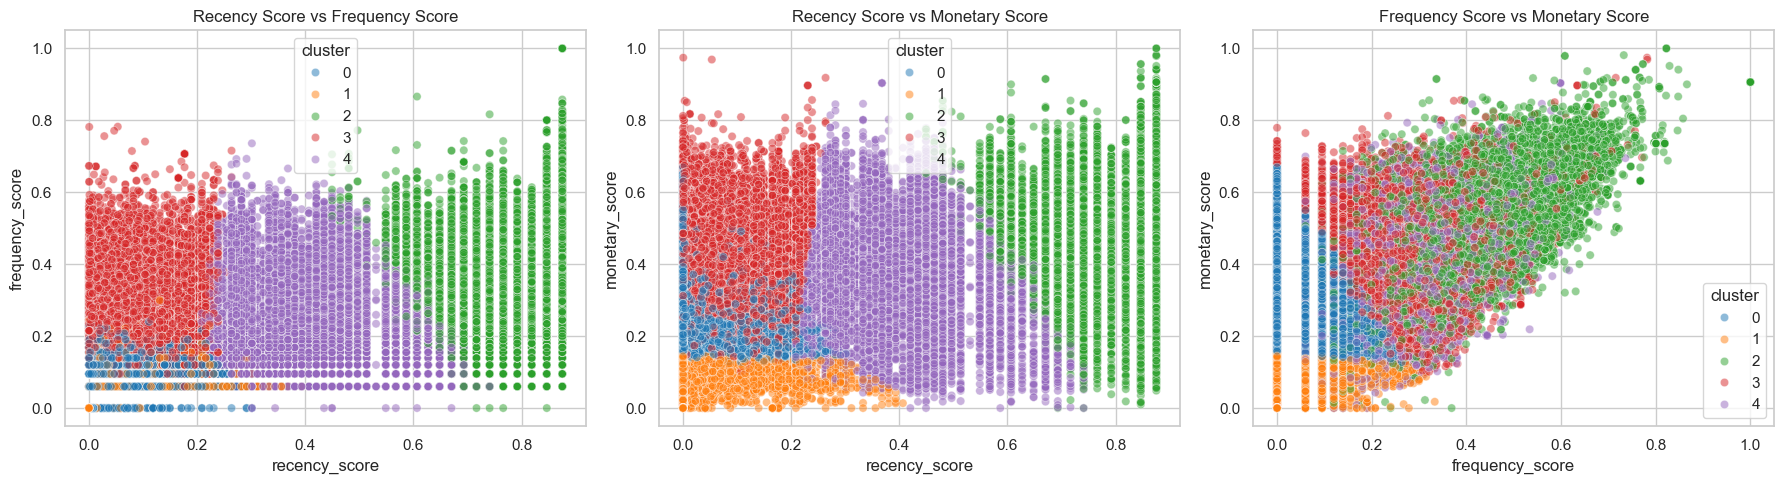

In [60]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus

DB_USER = ''
DB_PASS = ''
DB_HOST = ''
DB_PORT = ''
DB_NAME = ''

DB_PASS_ENCODED = quote_plus(DB_PASS)
DATABASE_URL = f"postgresql://{DB_USER}:{DB_PASS_ENCODED}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

sql_query = """
WITH accounts_map AS (
  SELECT login, client_id FROM ..
),

commission_agg AS (
  SELECT
    c.login,
    COALESCE(SUM(c.comission), 0) AS total_commission
  FROM .. c
  GROUP BY c.login
),

last_activity AS (
  SELECT
    am.client_id,
    GREATEST(
      COALESCE(MAX(t.date_last_activity), '1900-01-01'),
      COALESCE(MAX(e.date_last_conv), '1900-01-01'),
      COALESCE(MAX(io.date_last_inouts), '1900-01-01')
    ) AS last_activity_date
  FROM .. am
  LEFT JOIN freedom_broker.trades t ON am.login = t.login
  LEFT JOIN freedom_broker.exchange e ON am.client_id = e.client_id
  LEFT JOIN freedom_broker.inouts io ON am.client_id = io.client_id
  GROUP BY am.client_id
),

frequency AS (
  SELECT
    am.client_id,
    COALESCE(SUM(t.cnt_trades), 0) AS total_trades,
    COALESCE(SUM(io.cnt_inouts), 0) AS total_inouts,
    COALESCE(SUM(t.cnt_trades), 0) + COALESCE(SUM(io.cnt_inouts), 0) AS total_frequency
  FROM  am
  LEFT JOIN . t ON am.login = t.login
  LEFT JOIN . io ON am.client_id = io.client_id
  GROUP BY am.client_id
)

SELECT
  a.client_id,
  la.last_activity_date,
  f.total_frequency,
  b.balance,
  ins.sum_ins,
  co.total_commission,
  f.total_trades
FROM .. a
LEFT JOIN .. la ON a.client_id = la.client_id
LEFT JOIN .. f ON a.client_id = f.client_id
LEFT JOIN .. b ON a.client_id = b.client_id
LEFT JOIN .. ins ON a.client_id = ins.client_id
LEFT JOIN .. co ON a.login = co.login
;
"""

df = pd.read_sql(sql_query, engine)

df['last_activity_date'] = pd.to_datetime(df['last_activity_date'])
today = pd.Timestamp(datetime.utcnow().date())
df['recency'] = (today - df['last_activity_date']).dt.days

df.fillna({
    'total_frequency': 0,
    'balance': 0,
    'sum_ins': 0,
    'total_commission': 0,
    'total_trades': 0,
    'recency': df['recency'].max()
}, inplace=True)

multiplier = 1 + 0.05 * df['total_trades']
df['monetary_value'] = df['sum_ins'] * multiplier + df['total_commission']

df['total_frequency'] = df['total_frequency'].clip(lower=0)
df['monetary_value'] = df['monetary_value'].clip(lower=0)

half_life_days = 30
df['recency_score'] = np.exp(-df['recency'] / half_life_days)

df['frequency_score'] = np.log1p(df['total_frequency'])
df['frequency_score'] = (df['frequency_score'] - df['frequency_score'].min()) / (df['frequency_score'].max() - df['frequency_score'].min())

df['monetary_score'] = np.log1p(df['monetary_value'])
df['monetary_score'] = (df['monetary_score'] - df['monetary_score'].min()) / (df['monetary_score'].max() - df['monetary_score'].min())

df = df.dropna(subset=['recency_score', 'frequency_score', 'monetary_score'])

corrs = df[['recency_score', 'frequency_score', 'monetary_score', 'total_commission']].corr()
weights_raw = corrs.loc[['recency_score', 'frequency_score', 'monetary_score'], 'total_commission'].abs()
weights = weights_raw / weights_raw.sum()
print("Normalized weights based on correlation:\n", weights)

df['rfm_score'] = (
    df['recency_score'] * weights['recency_score'] +
    df['frequency_score'] * weights['frequency_score'] +
    df['monetary_score'] * weights['monetary_score']
)

kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(df[['recency_score', 'frequency_score', 'monetary_score']])

print("Cluster counts:")
print(df['cluster'].value_counts())

sns.set(style="whitegrid")
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.scatterplot(data=df, x='recency_score', y='frequency_score', hue='cluster', palette='tab10', alpha=0.5)
plt.title('Recency Score vs Frequency Score')

plt.subplot(1,3,2)
sns.scatterplot(data=df, x='recency_score', y='monetary_score', hue='cluster', palette='tab10', alpha=0.5)
plt.title('Recency Score vs Monetary Score')

plt.subplot(1,3,3)
sns.scatterplot(data=df, x='frequency_score', y='monetary_score', hue='cluster', palette='tab10', alpha=0.5)
plt.title('Frequency Score vs Monetary Score')

plt.tight_layout()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` 

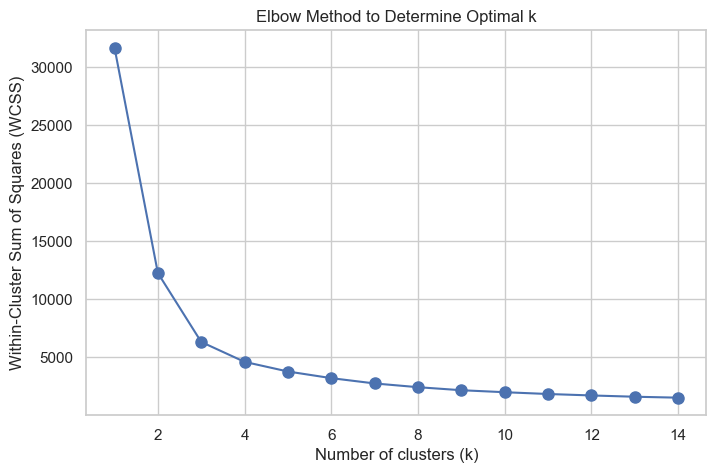

In [34]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
K = range(1, 15)  

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df[['recency_score', 'frequency_score', 'monetary_score']])
    wcss.append(kmeans.inertia_)  

plt.figure(figsize=(8, 5))
plt.plot(K, wcss, 'bo-', markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method to Determine Optimal k')
plt.show()



In [69]:
df.head(10)

,client_id,last_activity_date,total_frequency,balance,sum_ins,total_commission,total_trades,recency,monetary_value,recency_score,frequency_score,monetary_score,rfm_score,cluster
0,gAAAAABoJJwDG_D5rwTXB2DFmknUqBcPfdV8wwRI68GCFm...,1900-01-01,0.0,689.309532,0.000000e+00,0.000000,0.0,45792,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1
1,gAAAAABoJJwDguZPspoz3Tqk5SdU1MvGiOAd5w8W9LnHse...,2025-04-30,54.0,209.717374,9.441954e+03,97.068453,51.0,17,3.361600e+04,0.567414,0.346772,0.406358,0.429030,4
2,gAAAAABoJJwD40m0NdFjp42Z1kdE20IDurac_QRcirjmjk...,1900-01-01,0.0,1279.149754,0.000000e+00,0.000000,0.0,45792,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1
3,gAAAAABoJJwDgmKNCdoEYY_LJi8X1ue2SoziVVure9Wxjy...,2025-05-02,74.0,75877.592816,3.200966e+06,91.056464,12.0,15,5.121637e+06,0.606531,0.373611,0.602317,0.530191,2
4,gAAAAABoJJwDt69yns8XNka5fruKu0vIyqrICH83RL_Xko...,1900-01-01,0.0,2177.813125,5.661225e+03,0.000000,0.0,45792,5.661225e+03,0.000000,0.000000,0.336913,0.141722,0
5,gAAAAABoJJwDMItyjbVbKwUTuDZnDrjf_ul8bqnRb9ALMc...,1900-01-01,0.0,2338.338261,9.362509e+05,463.344771,0.0,45792,9.367143e+05,0.000000,0.000000,0.536083,0.225502,0
6,gAAAAABoJJwDg4imS2HbFaEgBDVzhyUnJD9HG98YcJ8iXS...,1900-01-01,0.0,8461.111354,0.000000e+00,11.080771,0.0,45792,1.108077e+01,0.000000,0.000000,0.097142,0.040863,1
7,gAAAAABoJJwDP9SMqyMuF6RLFBQl6FHAQ03emNR9FB-aNU...,1900-01-01,0.0,2257.692406,0.000000e+00,0.000000,0.0,45792,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1
8,gAAAAABoJJwDdMeEl2ak4fajHvPa9uKcdJ4w0bS10cCf1I...,1900-01-01,0.0,828.221025,0.000000e+00,0.000000,0.0,45792,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1
9,gAAAAABoJJwDMSfY71RlIVxWMEeyubEAytC4E1Wh4JBr7p...,2025-03-05,2.0,508.512747,5.633183e+00,0.000000,0.0,73,5.633183e+00,0.087744,0.095068,0.073768,0.084209,1


Total commission by cluster:
   cluster  total_commission
0        0      4.951218e+07
1        1      7.405090e+04
2        2      1.006881e+08
3        3      2.576475e+07
4        4      1.280772e+07


/var/folders/y7/l9071x9d45795hjk6vp7s96w0000gn/T/ipykernel_17191/552409013.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




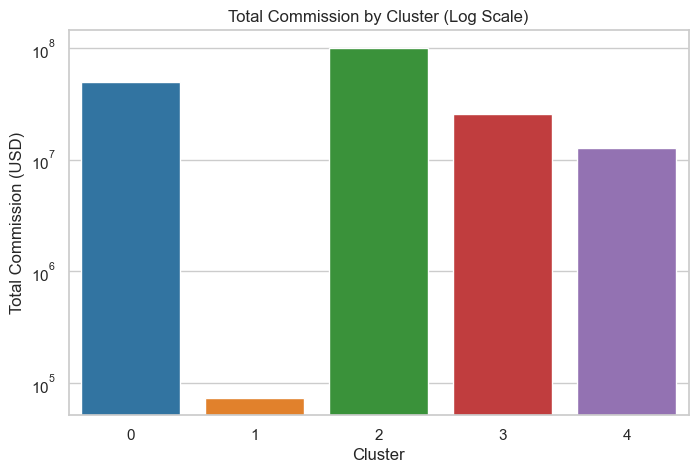

In [67]:

commission_by_cluster = df.groupby('cluster')['total_commission'].sum().reset_index()

print("Total commission by cluster:")
print(commission_by_cluster)

plt.figure(figsize=(8,5))
ax = sns.barplot(data=commission_by_cluster, x='cluster', y='total_commission', palette='tab10')
plt.title('Total Commission by Cluster (Log Scale)')
plt.xlabel('Cluster')
plt.ylabel('Total Commission (USD)')
plt.yscale('log')




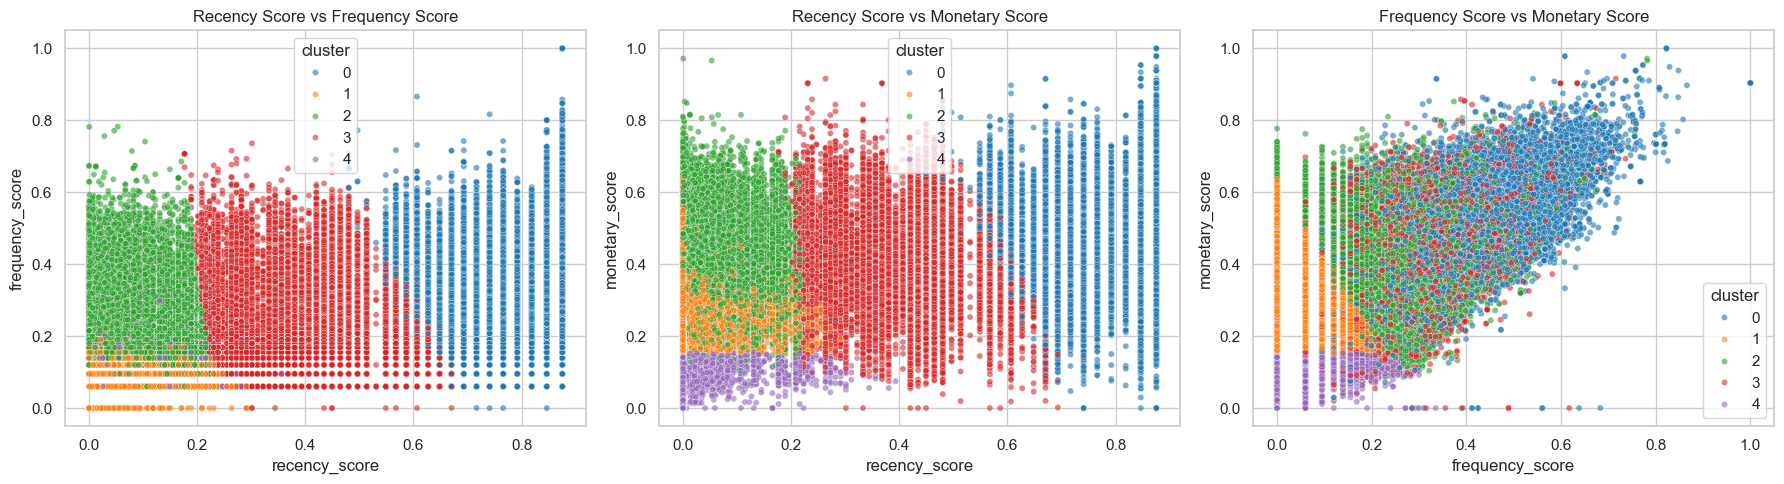

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x='recency_score', y='frequency_score', hue='cluster', palette='tab10', alpha=0.6, s=20)
plt.title('Recency Score vs Frequency Score')

plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x='recency_score', y='monetary_score', hue='cluster', palette='tab10', alpha=0.6, s=20)
plt.title('Recency Score vs Monetary Score')

plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x='frequency_score', y='monetary_score', hue='cluster', palette='tab10', alpha=0.6, s=20)
plt.title('Frequency Score vs Monetary Score')

plt.tight_layout()
plt.show()


/var/folders/y7/l9071x9d45795hjk6vp7s96w0000gn/T/ipykernel_17191/4220834164.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




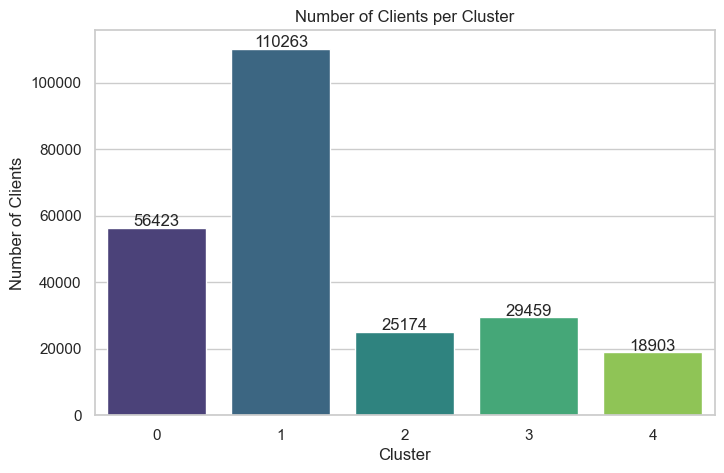

In [70]:
cluster_counts = df['cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
plt.xlabel('Cluster')
plt.ylabel('Number of Clients')
plt.title('Number of Clients per Cluster')
for i, count in enumerate(cluster_counts.values):
    plt.text(i, count + 500, str(count), ha='center')
plt.show()


/var/folders/y7/l9071x9d45795hjk6vp7s96w0000gn/T/ipykernel_17191/2394013501.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/y7/l9071x9d45795hjk6vp7s96w0000gn/T/ipykernel_17191/2394013501.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/y7/l9071x9d45795hjk6vp7s96w0000gn/T/ipykernel_17191/2394013501.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




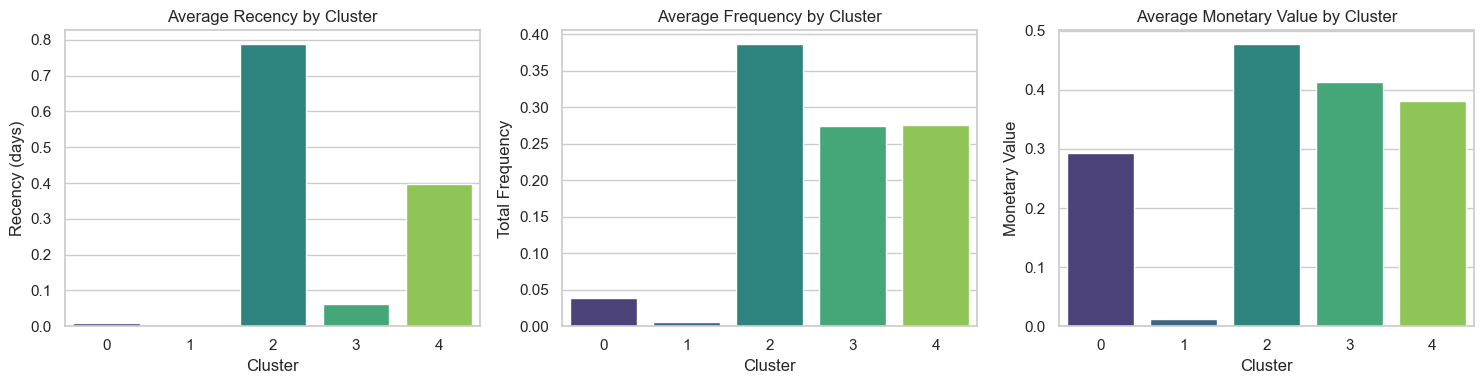

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns


cluster_features = df.groupby('cluster')[['recency_score', 'frequency_score', 'monetary_score']].mean().reset_index()

sns.set(style="whitegrid")
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.barplot(data=cluster_features, x='cluster', y='recency_score', palette='viridis')
plt.title('Average Recency by Cluster')
plt.ylabel('Recency (days)')
plt.xlabel('Cluster')

plt.subplot(1, 3, 2)
sns.barplot(data=cluster_features, x='cluster', y='frequency_score', palette='viridis')
plt.title('Average Frequency by Cluster')
plt.ylabel('Total Frequency')
plt.xlabel('Cluster')

plt.subplot(1, 3, 3)
sns.barplot(data=cluster_features, x='cluster', y='monetary_score', palette='viridis')
plt.title('Average Monetary Value by Cluster')
plt.ylabel('Monetary Value')
plt.xlabel('Cluster')

plt.tight_layout()
plt.show()


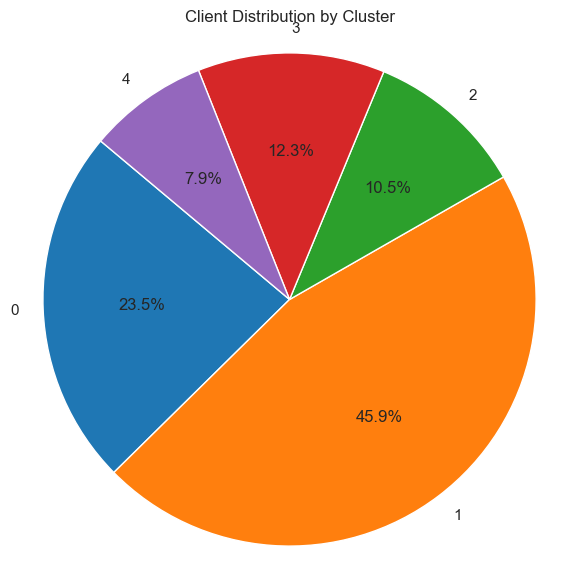

In [79]:
import matplotlib.pyplot as plt

cluster_counts = df['cluster'].value_counts().sort_index()

plt.figure(figsize=(7,7))
plt.pie(cluster_counts, labels=cluster_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab10.colors)
plt.title('Client Distribution by Cluster')
plt.axis('equal')  
plt.show()


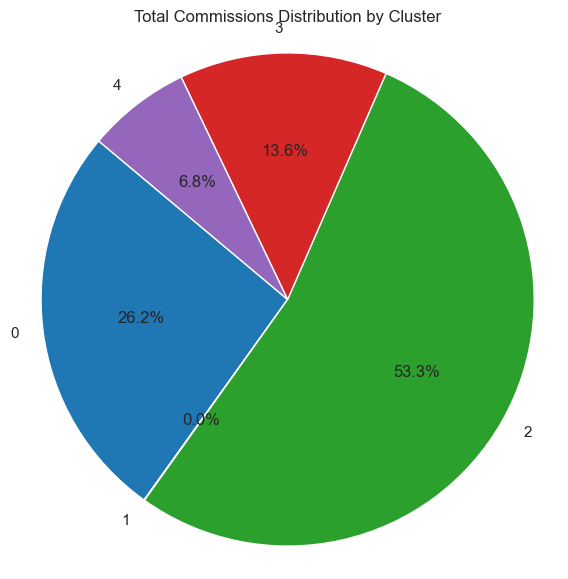

In [81]:

cluster_order = sorted(df['cluster'].unique())

commission_by_cluster = df.groupby('cluster')['total_commission'].sum().reindex(cluster_order)

plt.figure(figsize=(7,7))
plt.pie(commission_by_cluster, labels=commission_by_cluster.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab10.colors)
plt.title('Total Commissions Distribution by Cluster')
plt.axis('equal')  
plt.show()


In [84]:
df.head()

,client_id,last_activity_date,total_frequency,balance,sum_ins,total_commission,total_trades,recency,monetary_value,recency_score,frequency_score,monetary_score,rfm_score,cluster
0,gAAAAABoJJwDG_D5rwTXB2DFmknUqBcPfdV8wwRI68GCFm...,1900-01-01,0.0,689.309532,0.000000e+00,0.000000,0.0,45792,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1
1,gAAAAABoJJwDguZPspoz3Tqk5SdU1MvGiOAd5w8W9LnHse...,2025-04-30,54.0,209.717374,9.441954e+03,97.068453,51.0,17,3.361600e+04,0.567414,0.346772,0.406358,0.429030,4
2,gAAAAABoJJwD40m0NdFjp42Z1kdE20IDurac_QRcirjmjk...,1900-01-01,0.0,1279.149754,0.000000e+00,0.000000,0.0,45792,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1
3,gAAAAABoJJwDgmKNCdoEYY_LJi8X1ue2SoziVVure9Wxjy...,2025-05-02,74.0,75877.592816,3.200966e+06,91.056464,12.0,15,5.121637e+06,0.606531,0.373611,0.602317,0.530191,2
4,gAAAAABoJJwDt69yns8XNka5fruKu0vIyqrICH83RL_Xko...,1900-01-01,0.0,2177.813125,5.661225e+03,0.000000,0.0,45792,5.661225e+03,0.000000,0.000000,0.336913,0.141722,0


In [86]:
engine.dispose() 

Gender distribution (%) by cluster:
 sex_type          Ж          М  Не указано клиентом
cluster                                            
0         39.090531  58.121493             2.787975
1         37.199423  60.935330             1.865248
2         33.084967  66.594771             0.320261
3         35.580864  63.959200             0.459936
4         36.000394  63.595605             0.404001
Age segment distribution (%) by cluster:
 age_segment  18-24 лет  25-34 лет  35-44 лет  45-54 лет   55 лет +   <18 лет  \
cluster                                                                        
0            11.638498  30.215765  32.842696  16.113112   9.086029  0.006927   
1            22.048345  31.681248  28.389104  12.410932   5.350410  0.006314   
2             8.529412  21.222222  32.696078  21.983660  15.313725  0.000000   
3            10.190545  25.418479  33.675417  19.026313  11.445199  0.000000   
4            12.785141  25.511159  32.679706  18.766320  10.040893  0.000000 

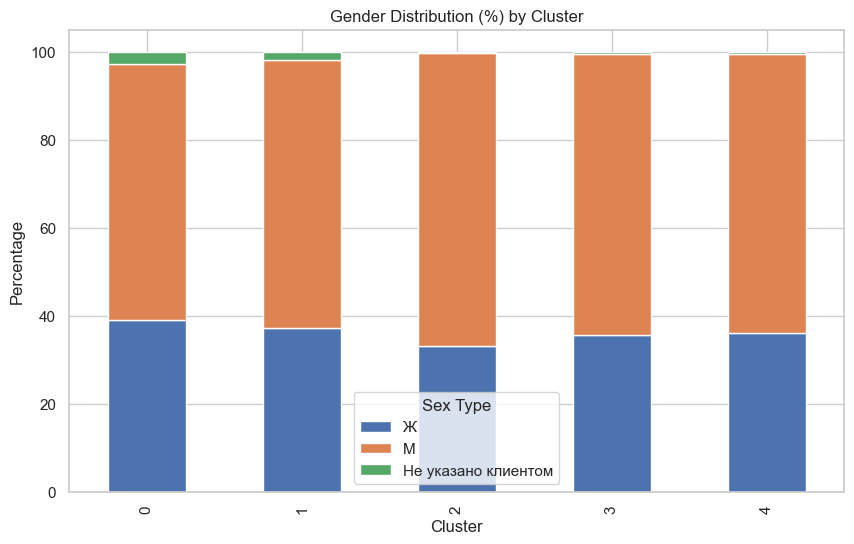

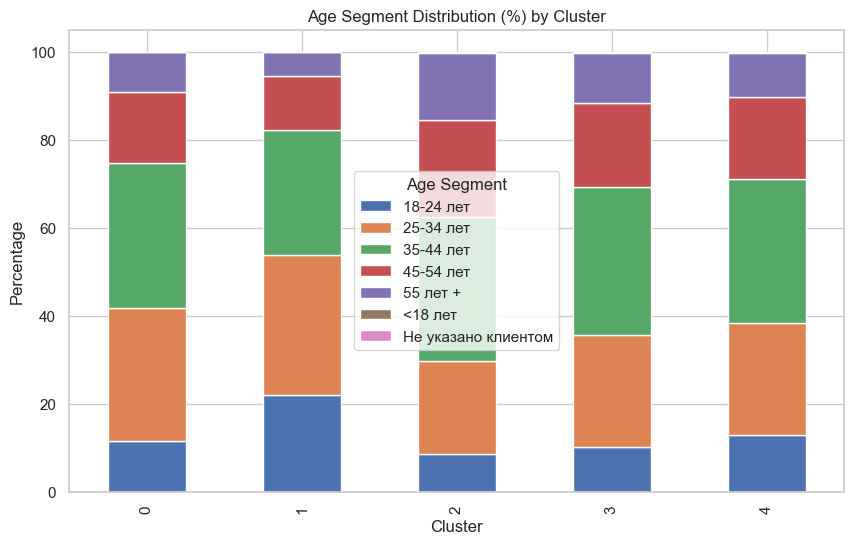

In [87]:

sql_demo = """
SELECT 
    client_id,
    age_segment,
    sex_type,
    "Канал привлечения",
    type
FROM ..
;
"""

with engine.connect() as conn:
    df_demo = pd.read_sql(sql_demo, conn)


df_full = df.merge(df_demo, on='client_id', how='left')

gender_dist = df_full.groupby(['cluster', 'sex_type']).size().unstack(fill_value=0)
gender_dist_percent = gender_dist.div(gender_dist.sum(axis=1), axis=0) * 100
print("Gender distribution (%) by cluster:\n", gender_dist_percent)

age_dist = df_full.groupby(['cluster', 'age_segment']).size().unstack(fill_value=0)
age_dist_percent = age_dist.div(age_dist.sum(axis=1), axis=0) * 100
print("Age segment distribution (%) by cluster:\n", age_dist_percent)

import matplotlib.pyplot as plt

gender_dist_percent.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Gender Distribution (%) by Cluster')
plt.ylabel('Percentage')
plt.xlabel('Cluster')
plt.legend(title='Sex Type')
plt.show()

age_dist_percent.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Age Segment Distribution (%) by Cluster')
plt.ylabel('Percentage')
plt.xlabel('Cluster')
plt.legend(title='Age Segment')
plt.show()


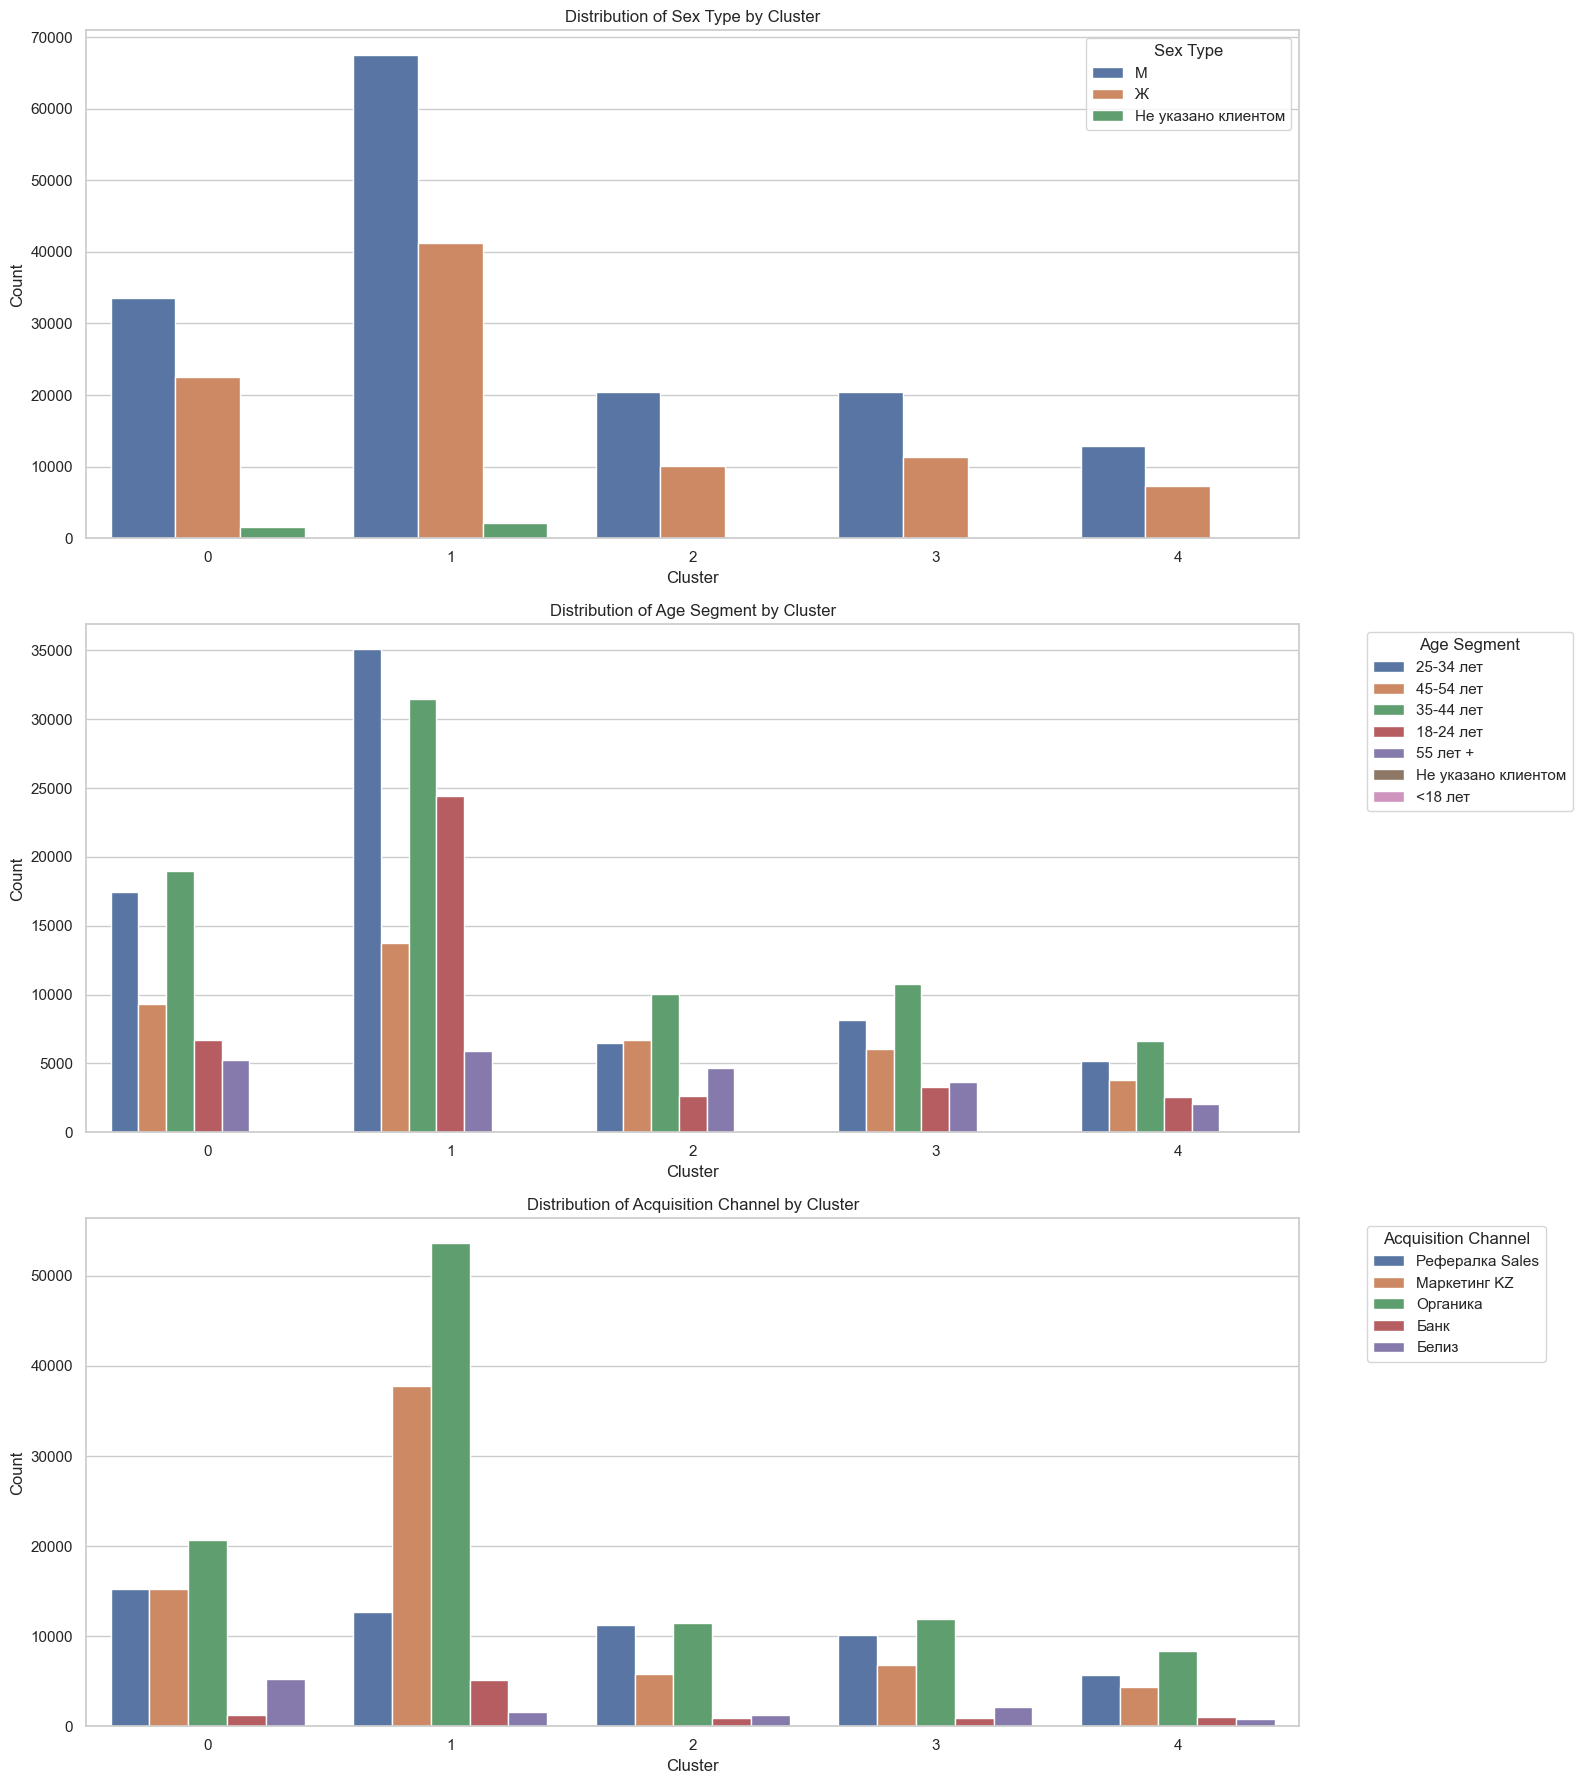

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 18))

# 1. Распределение по полу (sex_type) в разрезе кластеров
plt.subplot(3, 1, 1)
sns.countplot(data=df_full, x='cluster', hue='sex_type')
plt.title('Distribution of Sex Type by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Sex Type')

# 2. Распределение по возрастным сегментам (age_segment) в разрезе кластеров
plt.subplot(3, 1, 2)
sns.countplot(data=df_full, x='cluster', hue='age_segment')
plt.title('Distribution of Age Segment by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Age Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. Распределение по каналу привлечения (Канал привлечения) в разрезе кластеров
plt.subplot(3, 1, 3)
sns.countplot(data=df_full, x='cluster', hue='Канал привлечения')
plt.title('Distribution of Acquisition Channel by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Acquisition Channel', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [90]:

cluster_label_map = {
    2: "Top Value Customers",
    0: "Potentially Lost High-Value",
    3: "Active Mid-Tier Clients",
    4: "Emerging Growth Segment",
    1: "Low Activity, Low Value"
}

df['business_segment'] = df['cluster'].map(cluster_label_map)

print(df[['cluster', 'business_segment']].drop_duplicates().sort_values('cluster'))


    cluster             business_segment
4         0  Potentially Lost High-Value
0         1      Low Activity, Low Value
3         2          Top Value Customers
14        3      Active Mid-Tier Clients
1         4      Emerging Growth Segment


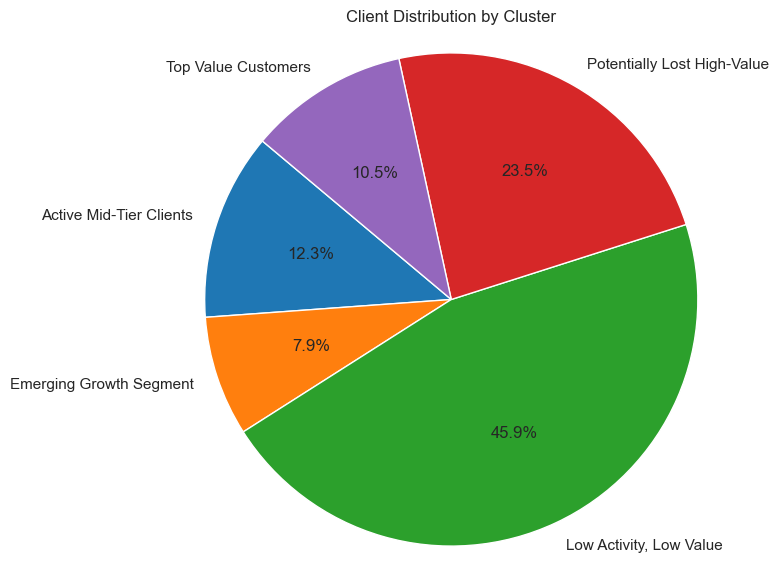

In [92]:
import matplotlib.pyplot as plt

cluster_counts = df['business_segment'].value_counts().sort_index()

plt.figure(figsize=(7,7))
plt.pie(cluster_counts, labels=cluster_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab10.colors)
plt.title('Client Distribution by Cluster')
plt.axis('equal')  
plt.show()


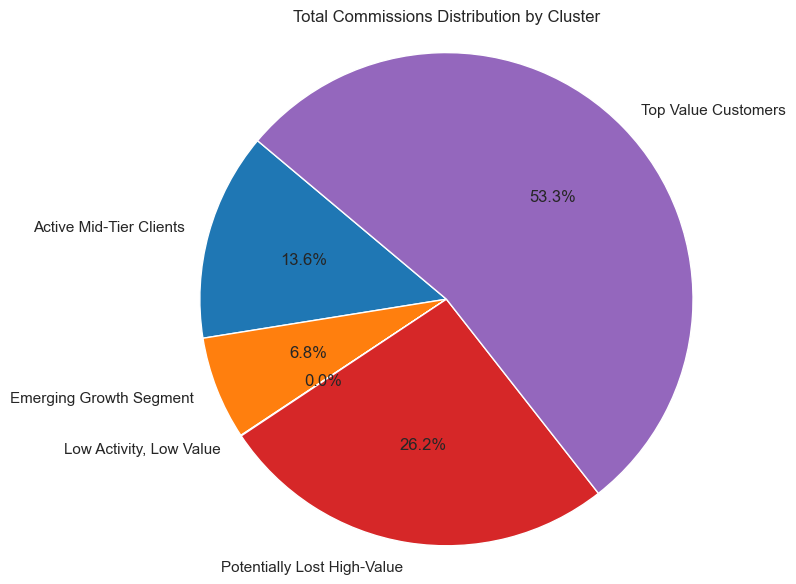

In [93]:

cluster_order = sorted(df['business_segment'].unique())


commission_by_cluster = df.groupby('business_segment')['total_commission'].sum().reindex(cluster_order)


plt.figure(figsize=(7,7))
plt.pie(commission_by_cluster, labels=commission_by_cluster.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab10.colors)
plt.title('Total Commissions Distribution by Cluster')
plt.axis('equal')  
plt.show()


In [95]:

cluster_label_map = {
    2: "Top Value Customers",
    0: "Potentially Lost High-Value",
    3: "Active Mid-Tier Clients",
    4: "Emerging Growth Segment",
    1: "Low Activity, Low Value"
}

df_full['business_segment'] = df_full['cluster'].map(cluster_label_map)

print(df_full[['cluster', 'business_segment']].drop_duplicates().sort_values('cluster'))


    cluster             business_segment
4         0  Potentially Lost High-Value
0         1      Low Activity, Low Value
3         2          Top Value Customers
14        3      Active Mid-Tier Clients
1         4      Emerging Growth Segment


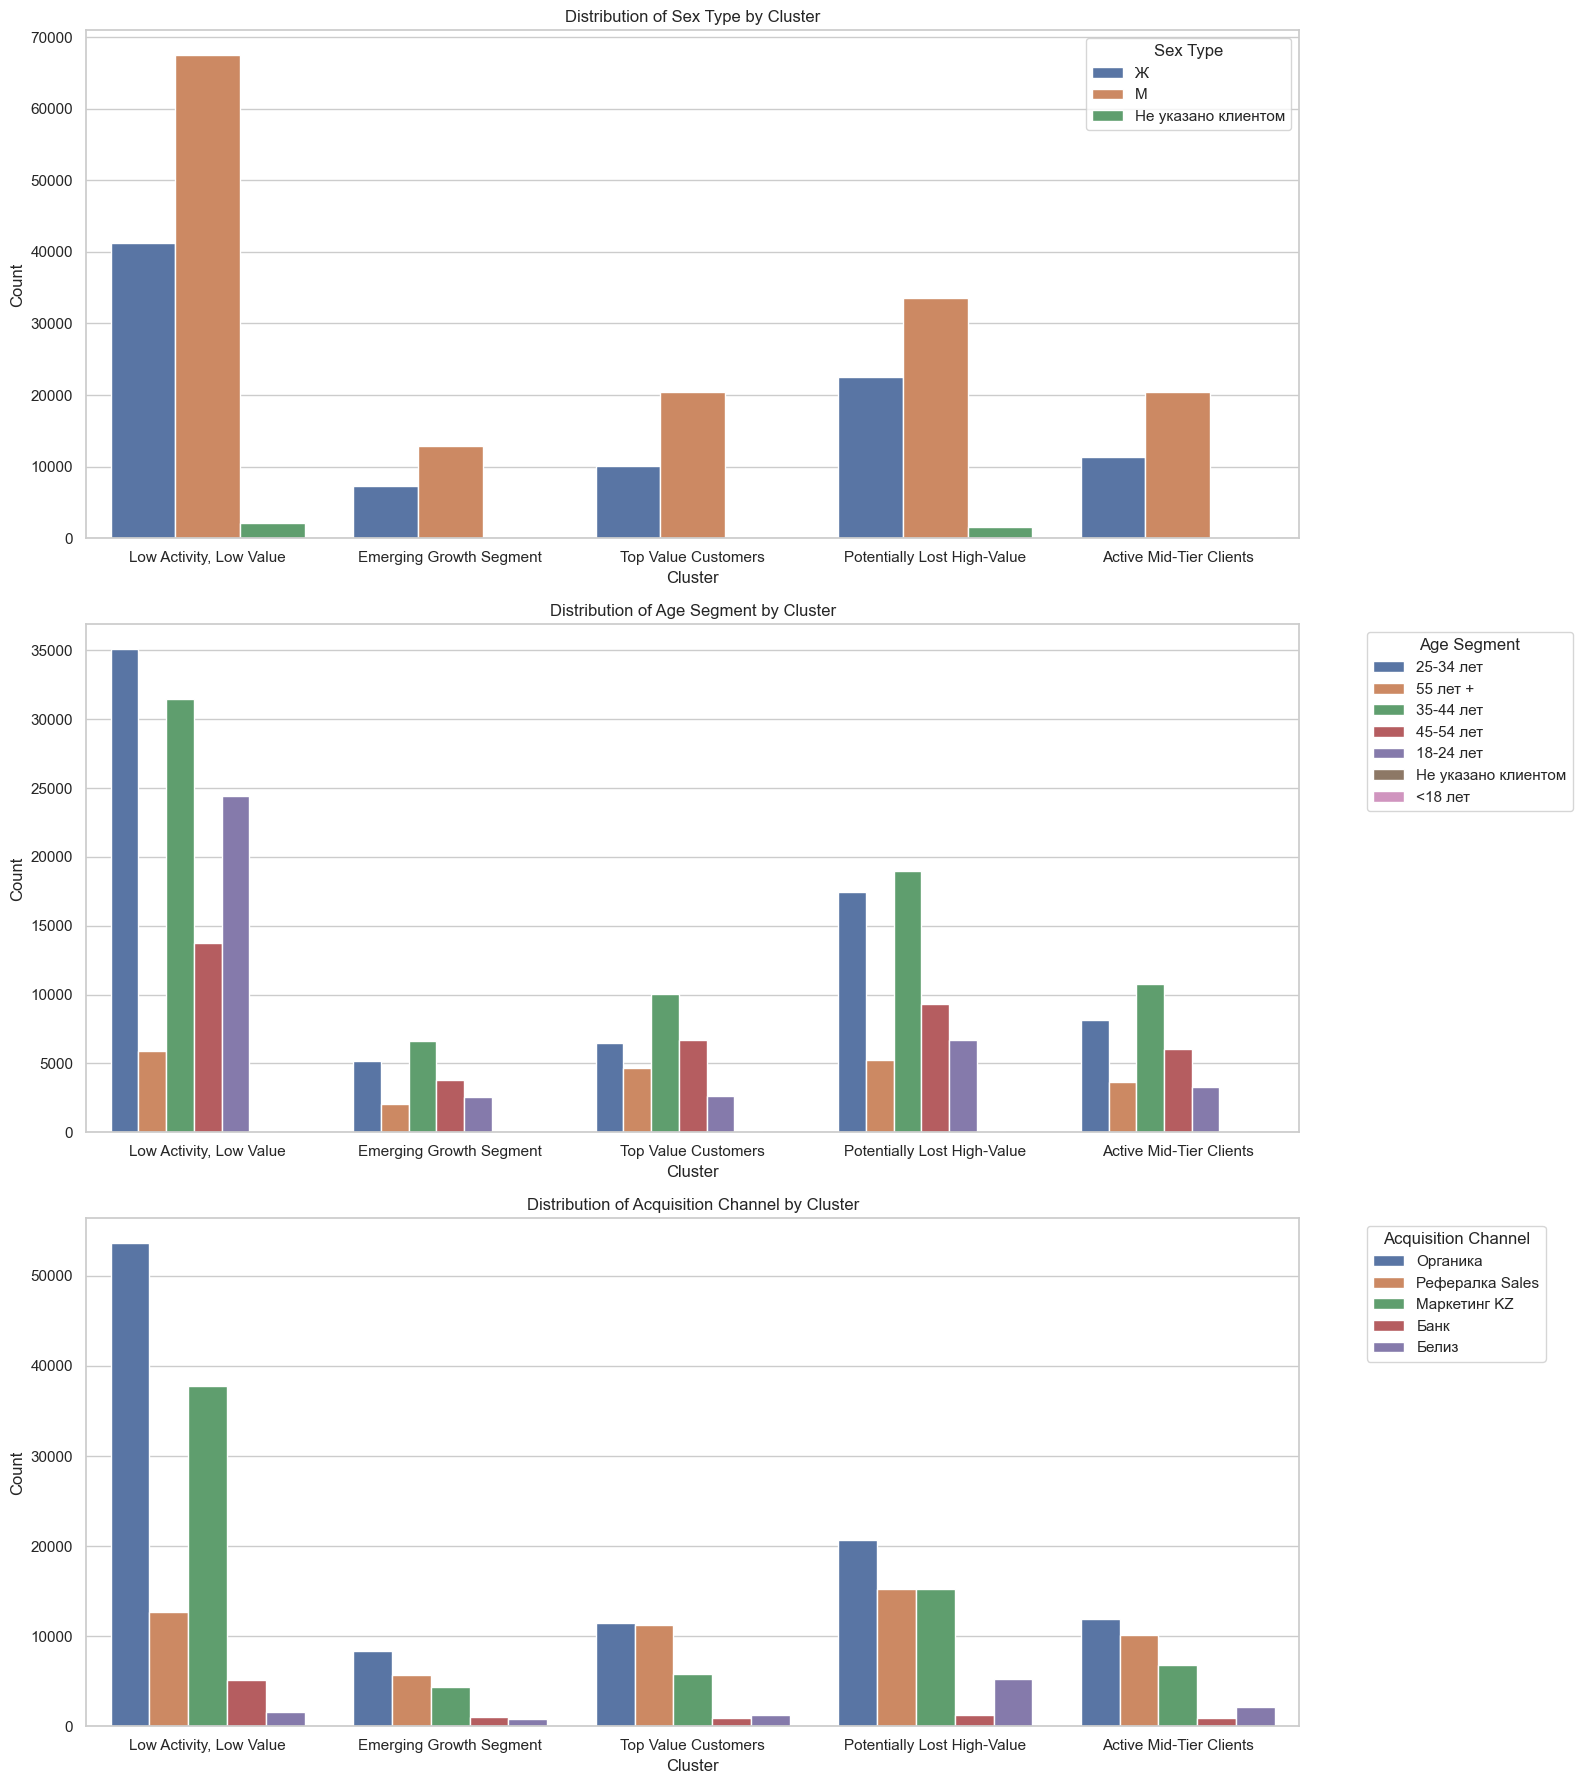

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 18))

# 1. Распределение по полу (sex_type) в разрезе кластеров
plt.subplot(3, 1, 1)
sns.countplot(data=df_full, x='business_segment', hue='sex_type')
plt.title('Distribution of Sex Type by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Sex Type')

# 2. Распределение по возрастным сегментам (age_segment) в разрезе кластеров
plt.subplot(3, 1, 2)
sns.countplot(data=df_full, x='business_segment', hue='age_segment')
plt.title('Distribution of Age Segment by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Age Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

# 3. Распределение по каналу привлечения (Канал привлечения) в разрезе кластеров
plt.subplot(3, 1, 3)
sns.countplot(data=df_full, x='business_segment', hue='Канал привлечения')
plt.title('Distribution of Acquisition Channel by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Acquisition Channel', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
